# Atoms & diatomics — reference bond-scan curves

Dissociation curves for the O/H atoms and diatomics (`b3lyp/def2-svpd`), from
`scripts/generate_bond_scan.py`. Singlets (H$_2$, OH$^-$, $^1$O$_2$) are broken-symmetry UKS so
they dissociate toward the atomic limit; open-shell states are ordinary UKS. Each diatomic is a
deterministic bond scan (the full internal coordinate); the atomic reference states pin the
dissociation asymptotes exactly.


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.chdir(os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd())

import json
import numpy as np
import torch
import matplotlib.pyplot as plt

from rsfff.mlip import DiabaticStateLibrary
from rsfff.train.data import load_datasets

torch.set_default_dtype(torch.float64)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True})
FIGDIR = "notebooks/figures"; os.makedirs(FIGDIR, exist_ok=True)

BOHR = 0.52917721067        # Angstrom / bohr
DEBYE = 4.803204            # e*Angstrom -> Debye
HA2EV = 27.211386           # Hartree -> eV
# polarizability is loaded in e^2*Ang^2/Ha; divide by Bohr^2 to get bohr^3 (a0^3 = e^2 a0^2/Ha)
POL_TO_BOHR3 = 1.0 / BOHR**2

lib = DiabaticStateLibrary.from_yaml("data/diabatic_states.yaml")
ref = {(s["symbol"], s["charge"]): s
       for s in json.load(open("data/atomic_reference_states.json"))["states"]}
Eref = lambda sym, q: ref[(sym, q)]["energy"]

# diatomic key -> (label, colour, dissociation-limit energy = sum of atomic references)
DIATOMICS = {
    "h2_q0_m1":  (r"H$_2$ $^1\Sigma$",            "#2166ac", 2 * Eref("H", 0)),
    "h2_q0_m3":  (r"H$_2$ $^3\Sigma$ (repulsive)", "#67a9cf", 2 * Eref("H", 0)),
    "oh_q0_m2":  (r"OH $^2\Pi$",                   "#1b7837", Eref("O", 0) + Eref("H", 0)),
    "oh_q-1_m1": (r"OH$^-$",                        "#5aae61", Eref("O", -1) + Eref("H", 0)),
    "o2_q0_m3":  (r"O$_2$ $^3\Sigma$",             "#b2182b", 2 * Eref("O", 0)),
    "o2_q0_m1":  (r"$^1$O$_2$",                     "#ef8a62", 2 * Eref("O", 0)),
    "o2_q-1_m2": (r"O$_2^-$",                       "#762a83", Eref("O", -1) + Eref("O", 0)),
}

def load_scan(key):
    """Bond scan sorted by bond length: r [A], E [Ha], |mu| [D], alpha_iso & anisotropy [bohr^3]."""
    ds = load_datasets([f"data/labels/{key}.extxyz"], dtype=torch.float64, library=lib)
    b = ds.flat_batch(torch.arange(len(ds))); n = len(ds)
    pos = b.positions.reshape(n, 2, 3).numpy()
    r = np.linalg.norm(pos[:, 1] - pos[:, 0], axis=1)
    dip = np.linalg.norm(b.dipole.numpy(), axis=1) * DEBYE
    al = b.polarizability.numpy() * POL_TO_BOHR3
    aiso = np.trace(al, axis1=1, axis2=2) / 3
    aan = al[:, 2, 2] - (al[:, 0, 0] + al[:, 1, 1]) / 2      # bond is along z
    o = np.argsort(r)
    return dict(r=r[o], E=b.energy.numpy()[o], dip=dip[o], aiso=aiso[o], aan=aan[o])

S = {k: load_scan(k) for k in DIATOMICS}
print({k: len(v["r"]) for k, v in S.items()})

{'h2_q0_m1': 66, 'h2_q0_m3': 66, 'oh_q0_m2': 47, 'oh_q-1_m1': 47, 'o2_q0_m3': 49, 'o2_q0_m1': 33, 'o2_q-1_m2': 41}


## 1. Potential energy curves

Energy relative to the dissociation limit (sum of atomic reference energies). H$_2$ shows the
bound singlet vs the repulsive triplet; both go to $2E(\mathrm{H})$. The O$_2$ family is the
hardest to dissociate cleanly (branch-jumping / slow tail at large $r$), which is expected for
single-reference bond-breaking.


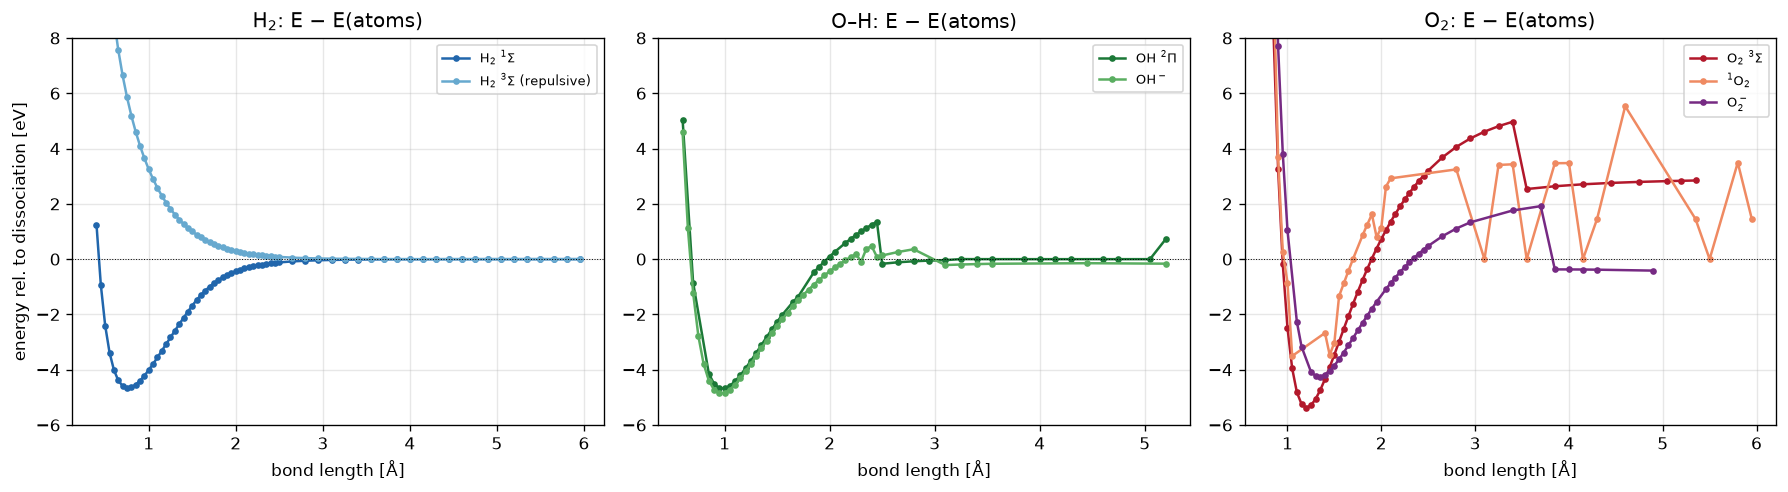

In [2]:
groups = [("H$_2$", ["h2_q0_m1", "h2_q0_m3"]),
          ("O\u2013H", ["oh_q0_m2", "oh_q-1_m1"]),
          ("O$_2$", ["o2_q0_m3", "o2_q0_m1", "o2_q-1_m2"])]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (title, keys) in zip(axes, groups):
    for k in keys:
        lb, c, lim = DIATOMICS[k]; d = S[k]
        ax.plot(d["r"], (d["E"] - lim) * HA2EV, "o-", ms=3, lw=1.5, color=c, label=lb)
    ax.axhline(0, color="k", lw=0.6, ls=":")
    ax.set_title(f"{title}: E \u2212 E(atoms)"); ax.set_xlabel("bond length [\u00c5]")
    ax.legend(fontsize=8); ax.set_ylim(-6, 8)
axes[0].set_ylabel("energy rel. to dissociation [eV]")
fig.tight_layout(); fig.savefig(f"{FIGDIR}/diatomic_energy.png", bbox_inches="tight"); plt.show()

## 2. Dipole and polarizability along the bond

Homonuclear neutrals (H$_2$, O$_2$) have zero dipole; OH/OH$^-$ are polar; O$_2^-$ develops a
large dipole as it separates into O$^-$+O. The isotropic polarizability grows as the bond
stretches. The analytic finite-field polarizability diverges at the few near-degenerate SCF
points, so unphysical values are masked.


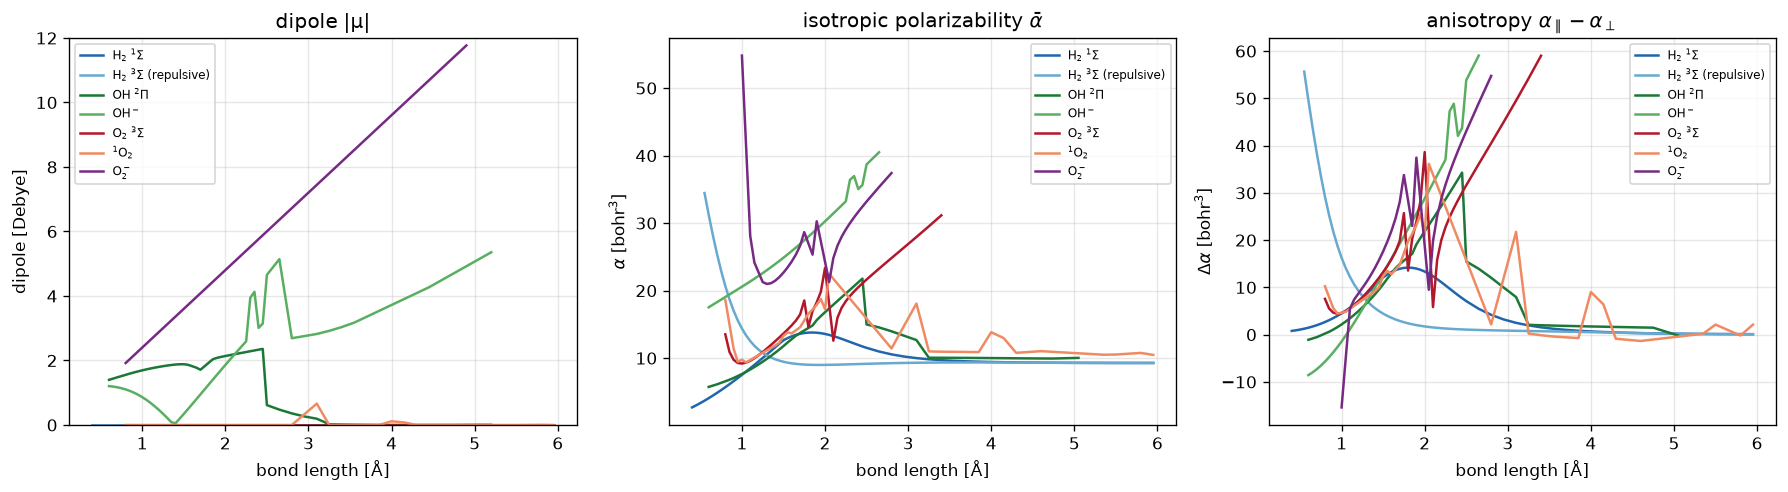

In [3]:
def valid(d):
    return (d["aiso"] > 0) & (d["aiso"] < 60) & (np.abs(d["aan"]) < 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for k, d in S.items():
    lb, c, _ = DIATOMICS[k]; m = valid(d)
    axes[0].plot(d["r"], d["dip"], "-", lw=1.5, color=c, label=lb)
    axes[1].plot(d["r"][m], d["aiso"][m], "-", lw=1.5, color=c, label=lb)
    axes[2].plot(d["r"][m], d["aan"][m], "-", lw=1.5, color=c, label=lb)
axes[0].set_title("dipole |\u03bc|"); axes[0].set_ylabel("dipole [Debye]"); axes[0].set_ylim(0, 12)
axes[1].set_title(r"isotropic polarizability $\bar\alpha$"); axes[1].set_ylabel(r"$\alpha$ [bohr$^3$]")
axes[2].set_title(r"anisotropy $\alpha_\parallel-\alpha_\perp$"); axes[2].set_ylabel(r"$\Delta\alpha$ [bohr$^3$]")
for ax in axes:
    ax.set_xlabel("bond length [\u00c5]"); ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(f"{FIGDIR}/diatomic_response.png", bbox_inches="tight"); plt.show()

## 3. Atomic reference states

The isolated-atom anchors the diatomics dissociate to: energy vs charge (IP/EA slopes) and
isotropic polarizability vs charge. H$^-$ and O$^{2-}$ are unbound at this level (diffuse,
large $\alpha$) and flagged in the data.


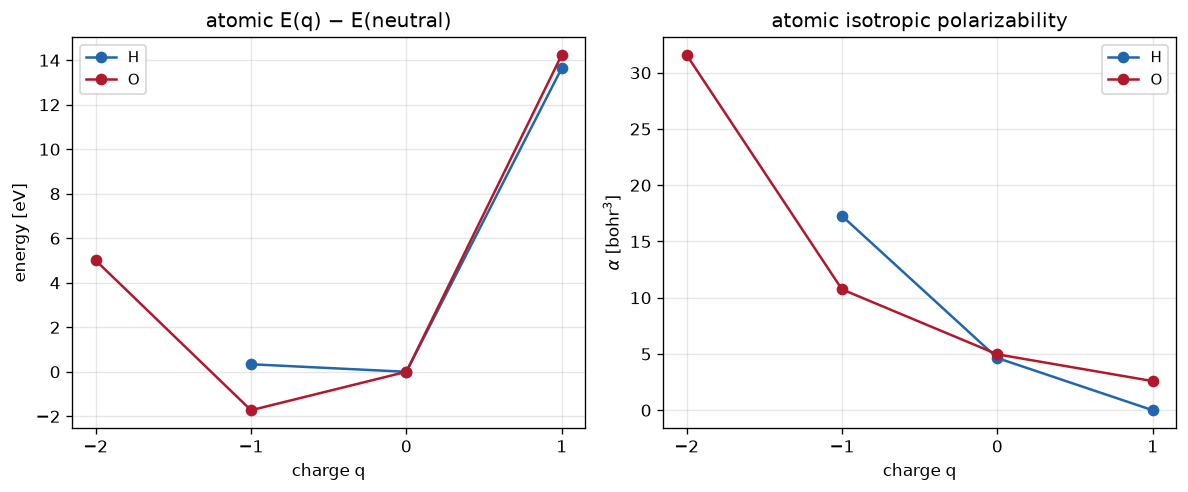

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for sym, col in [("H", "#2166ac"), ("O", "#b2182b")]:
    qs = sorted(q for (s, q) in ref if s == sym)
    e0 = Eref(sym, 0)
    axes[0].plot(qs, [(Eref(sym, q) - e0) * HA2EV for q in qs], "o-", color=col, label=sym)
    axes[1].plot(qs, [np.trace(np.array(ref[(sym, q)]["polarizability"])) / 3 for q in qs],
                 "o-", color=col, label=sym)
axes[0].set_title("atomic E(q) \u2212 E(neutral)"); axes[0].set_ylabel("energy [eV]")
axes[1].set_title("atomic isotropic polarizability"); axes[1].set_ylabel(r"$\alpha$ [bohr$^3$]")
for ax in axes:
    ax.set_xlabel("charge q"); ax.set_xticks([-2, -1, 0, 1]); ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig(f"{FIGDIR}/atomic_states.png", bbox_inches="tight"); plt.show()